# Advanced Data Analysis and Visualization in Logistics

**Dataset:** `logistics_clean.csv` — 112,635 order-item records from an e-commerce fulfillment operation (Sept 2016 – Sept 2018)

This notebook performs an end-to-end exploratory data analysis (EDA) of logistics/delivery performance: data loading, descriptive statistics, correlation analysis, segmentation by category/geography, and ten visualizations with interpretation.

**Tools:** pandas, numpy, matplotlib, seaborn


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = "#2E5EAA"
ACCENT = "#E8743B"
%matplotlib inline

df = pd.read_csv('logistics_clean.csv')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

print(df.shape)
df.head()


(112635, 25)


,order_id,order_item_id,product_id,seller_id,customer_id,order_status,is_delivered,product_category_name_english,price,freight_value,...,delivery_delay_days,carrier_transit_days,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_state,seller_state,freight_outlier,purchase_month
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,3ce436f183e68e07877b285a838db11a,delivered,1,cool_stuff,58.90,13.29,...,-8.011250,1.214954,650.0,28.0,9.0,14.0,rj,sp,False,2017-09
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,f6dd3ec061db4e3987629fe6b26e5cce,delivered,1,pet_shop,239.90,19.93,...,-2.330278,8.062083,30000.0,50.0,30.0,40.0,sp,sp,False,2017-04
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,6489ae5e4333f3693df5ad4372dab6d3,delivered,1,furniture_decor,199.00,17.87,...,-13.444954,6.029491,3050.0,33.0,13.0,33.0,mg,mg,False,2018-01
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,d4eb9395c8c0431ee92fce09860c5a06,delivered,1,perfumery,12.99,12.79,...,-5.435660,4.003229,200.0,16.0,10.0,15.0,sp,sp,False,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,58dbd0b2d70206bf40e62cd34e84d795,delivered,1,garden_tools,199.90,18.14,...,-15.303808,13.289144,3750.0,35.0,40.0,30.0,sp,pr,False,2017-02


In [2]:
df.dtypes


order_id                                    str
order_item_id                             int64
product_id                                  str
seller_id                                   str
customer_id                                 str
order_status                                str
is_delivered                              int64
product_category_name_english               str
price                                   float64
freight_value                           float64
order_purchase_timestamp         datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date               str
delivery_days                           float64
delivery_days_capped                    float64
delivery_delay_days                     float64
carrier_transit_days                    float64
product_weight_g                        float64
product_length_cm                       float64
product_height_cm                       float64
product_width_cm                        

In [3]:
df.isnull().sum()


order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
customer_id                         0
order_status                        0
is_delivered                        0
product_category_name_english       0
price                               0
freight_value                       0
order_purchase_timestamp            0
order_delivered_customer_date    2454
order_estimated_delivery_date       0
delivery_days                    2454
delivery_days_capped             2454
delivery_delay_days              2454
carrier_transit_days             2455
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
customer_state                      0
seller_state                        0
freight_outlier                     0
purchase_month                      0
dtype: int64

Only `order_delivered_customer_date` and its derived columns (`delivery_days`, `delivery_days_capped`, `delivery_delay_days`, `carrier_transit_days`) have missing values (~2,454 rows) — these correspond to orders not yet delivered. We filter to delivered orders for all delivery-timing analysis.

In [4]:
delivered = df[df['is_delivered'] == 1].copy()
delivered['is_late'] = delivered['delivery_delay_days'] > 0
delivered['same_state'] = delivered['customer_state'] == delivered['seller_state']

print(f"Total rows: {len(df):,}")
print(f"Delivered rows: {len(delivered):,}")
print(f"Unique orders: {df['order_id'].nunique():,}")
print(f"Unique products: {df['product_id'].nunique():,}")
print(f"Unique sellers: {df['seller_id'].nunique():,}")
print(f"Product categories: {df['product_category_name_english'].nunique()}")
print(f"Date range: {df['order_purchase_timestamp'].min()} to {df['order_purchase_timestamp'].max()}")


Total rows: 112,635
Delivered rows: 110,181
Unique orders: 98,652
Unique products: 32,948
Unique sellers: 3,095
Product categories: 72
Date range: 2016-09-04 21:15:19 to 2018-09-03 09:06:57


## 2. Exploratory Data Analysis

### 2.1 Central Tendency & Dispersion

In [5]:
delivered['delivery_days'].describe()


count    110181.000000
mean         12.472531
std           9.446250
min           0.533414
25%           6.735718
50%          10.184039
75%          15.541956
max         209.628611
Name: delivery_days, dtype: float64

In [6]:
delivered['delivery_delay_days'].describe()


count    110181.000000
mean        -11.331776
std          10.162127
min        -146.016123
25%         -16.319757
50%         -12.045394
75%          -6.476053
max         188.975081
Name: delivery_delay_days, dtype: float64

In [7]:
pct_late = (delivered['delivery_delay_days'] > 0).mean() * 100
print(f"Orders delivered late (past estimated date): {pct_late:.2f}%")


Orders delivered late (past estimated date): 7.91%


In [8]:
df[['price', 'freight_value']].describe()


,price,freight_value
count,112635.000000,112635.000000
mean,120.654976,19.990459
std,183.642573,15.807244
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


### 2.2 Correlation Analysis

In [9]:
cols = ['price', 'freight_value', 'delivery_days', 'delivery_delay_days',
        'carrier_transit_days', 'product_weight_g']
corr = delivered[cols].corr().round(3)
corr


,price,freight_value,delivery_days,delivery_delay_days,carrier_transit_days,product_weight_g
price,1.000,0.413,0.062,-0.004,0.041,0.336
freight_value,0.413,1.000,0.215,-0.040,0.196,0.608
delivery_days,0.062,0.215,1.000,0.597,0.922,0.086
delivery_delay_days,-0.004,-0.040,0.597,1.000,0.569,0.012
carrier_transit_days,0.041,0.196,0.922,0.569,1.000,0.031
product_weight_g,0.336,0.608,0.086,0.012,0.031,1.000


**Key relationship:** `carrier_transit_days` correlates almost perfectly with `delivery_days` (r ≈ 0.92) — carrier transit time, not order processing, is the dominant driver of total delivery time. `freight_value` correlates moderately with `product_weight_g` (r ≈ 0.61), consistent with weight-based shipping pricing.

### 2.3 Segmented Analysis: Category, State, and Shipment Distance

In [10]:
cat_counts = delivered['product_category_name_english'].value_counts()
top_cats = cat_counts[cat_counts > 1500].index
category_delivery = (delivered[delivered['product_category_name_english'].isin(top_cats)]
                      .groupby('product_category_name_english')['delivery_days']
                      .agg(['mean', 'count'])
                      .sort_values('mean', ascending=False))
category_delivery.head(10)


,mean,count
product_category_name_english,,
office_furniture,20.841449,1668
garden_tools,13.708863,4267
computers_accessories,13.225304,7643
electronics,12.885882,2729
furniture_decor,12.879393,8157
telephony,12.862529,4428
bed_bath_table,12.806370,10952
stationery,12.736789,2466
unknown_category,12.734784,1558


In [11]:
state_counts = df['customer_state'].value_counts().head(8)
state_delivery = delivered.groupby('customer_state')['delivery_days'].mean().loc[state_counts.index].sort_values(ascending=False)
state_late_rate = (delivered.groupby('customer_state')['is_late'].mean().loc[state_counts.index] * 100).sort_values(ascending=False)

print("Average delivery days by state (top 8 by volume):")
print(state_delivery)
print()
print("Late-delivery rate (%) by state:")
print(state_late_rate)


Average delivery days by state (top 8 by volume):
customer_state
ba    19.247618
rs    15.189325
rj    15.149133
sc    15.001540
df    12.958993
mg    11.982944
pr    11.947217
sp     8.723523
Name: delivery_days, dtype: float64

Late-delivery rate (%) by state:
customer_state
ba    13.684496
rj    12.974616
sc     9.614446
df     7.430998
rs     6.883053
sp     5.768982
mg     5.451448
pr     4.779607
Name: is_late, dtype: float64


In [12]:
same_state_comparison = delivered.groupby('same_state').agg(
    avg_delivery_days=('delivery_days', 'mean'),
    late_rate_pct=('is_late', lambda x: x.mean() * 100),
    order_count=('delivery_days', 'count')
)
same_state_comparison.index = ['Cross-State', 'Same-State']
same_state_comparison


,avg_delivery_days,late_rate_pct,order_count
Cross-State,15.049941,9.002873,70322
Same-State,7.925286,5.981083,39859


## 3. Visualizations

Ten charts, each chosen to match a specific analytical question (distribution, trend, comparison, relationship, correlation).

### 3.1 Distribution of Delivery Times

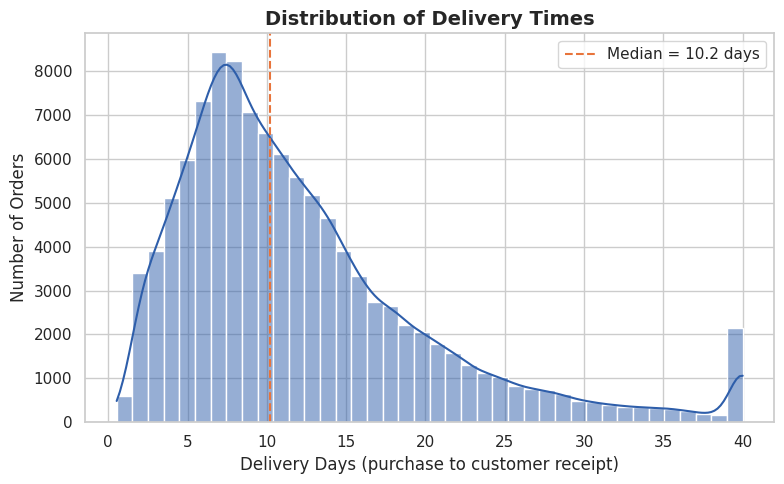

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(delivered['delivery_days'].clip(upper=40), bins=40, kde=True, color=PALETTE, ax=ax)
ax.axvline(delivered['delivery_days'].median(), color=ACCENT, linestyle='--',
           label=f"Median = {delivered['delivery_days'].median():.1f} days")
ax.set_title('Distribution of Delivery Times', fontsize=14, weight='bold')
ax.set_xlabel('Delivery Days (purchase to customer receipt)')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.show()


**Insight:** Right-skewed distribution — most orders arrive within 6-16 days, but a long tail extends past 30 days. This tail is the highest-value target for operational intervention.

### 3.2 Delivery Delay Distribution (On-Time Performance)

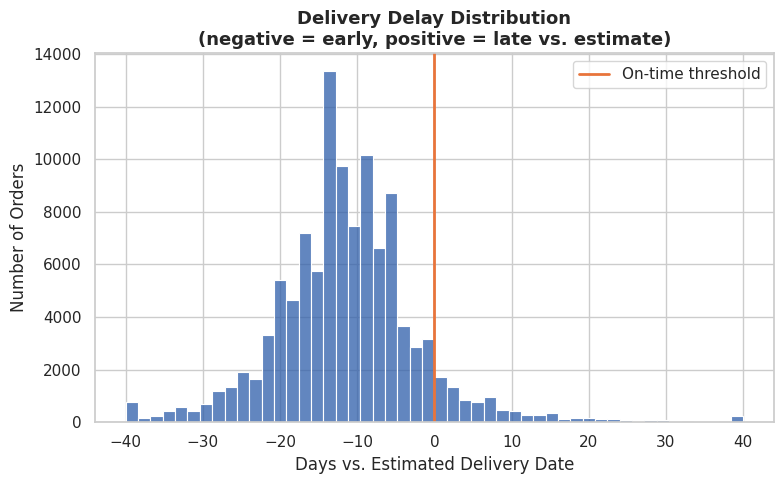

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(delivered['delivery_delay_days'].clip(-40, 40), bins=50, color=PALETTE, ax=ax)
ax.axvline(0, color=ACCENT, linewidth=2, label='On-time threshold')
ax.set_title('Delivery Delay Distribution\n(negative = early, positive = late vs. estimate)', fontsize=13, weight='bold')
ax.set_xlabel('Days vs. Estimated Delivery Date')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.show()


**Insight:** The bulk of orders arrive well ahead of the promised date, showing built-in slack in estimates. The small right tail (7.9% of orders) represents genuine late deliveries.

### 3.3 Monthly Shipment Volume Trend

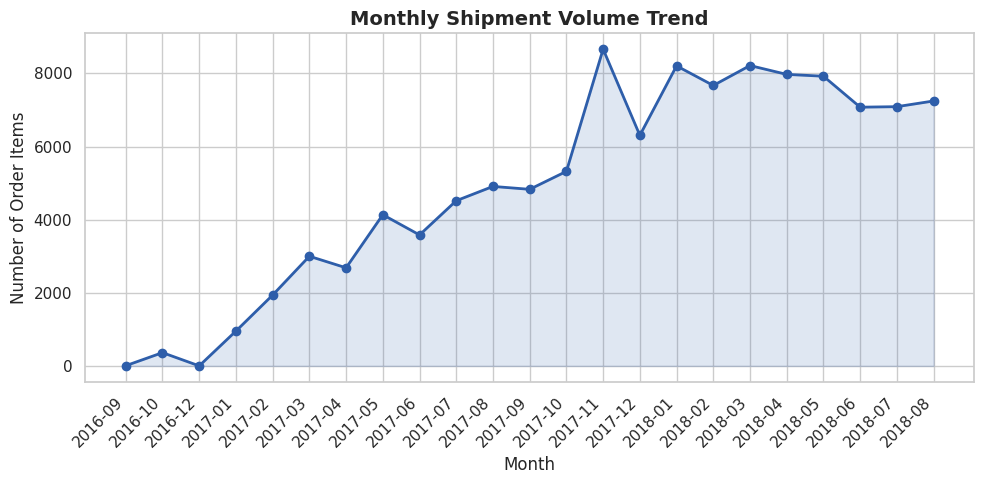

In [15]:
monthly = df[df['purchase_month'] != '2018-09'].groupby('purchase_month').size()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly.index, monthly.values, marker='o', color=PALETTE, linewidth=2)
ax.fill_between(range(len(monthly)), monthly.values, alpha=0.15, color=PALETTE)
ax.set_title('Monthly Shipment Volume Trend', fontsize=14, weight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Order Items')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Insight:** Volume grows steadily through 2017 with a sharp November spike (Black Friday season) before plateauing at a higher baseline in 2018 — a natural cue for seasonal capacity planning.

### 3.4 Average Delivery Time by Product Category

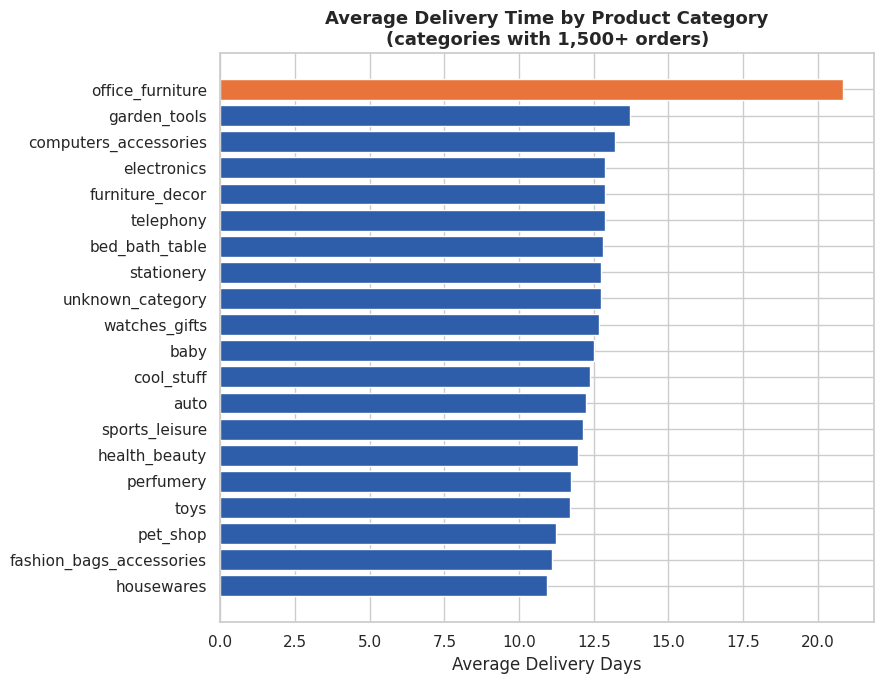

In [16]:
g = category_delivery['mean']
fig, ax = plt.subplots(figsize=(9, 7))
colors = [ACCENT if v == g.max() else PALETTE for v in g.values]
ax.barh(g.index, g.values, color=colors)
ax.invert_yaxis()
ax.set_title('Average Delivery Time by Product Category\n(categories with 1,500+ orders)', fontsize=13, weight='bold')
ax.set_xlabel('Average Delivery Days')
plt.tight_layout()
plt.show()


**Insight:** Office furniture is a clear outlier at ~21 days — nearly double the fastest categories — consistent with bulky, harder-to-ship goods.

### 3.5 Freight Cost vs. Product Weight

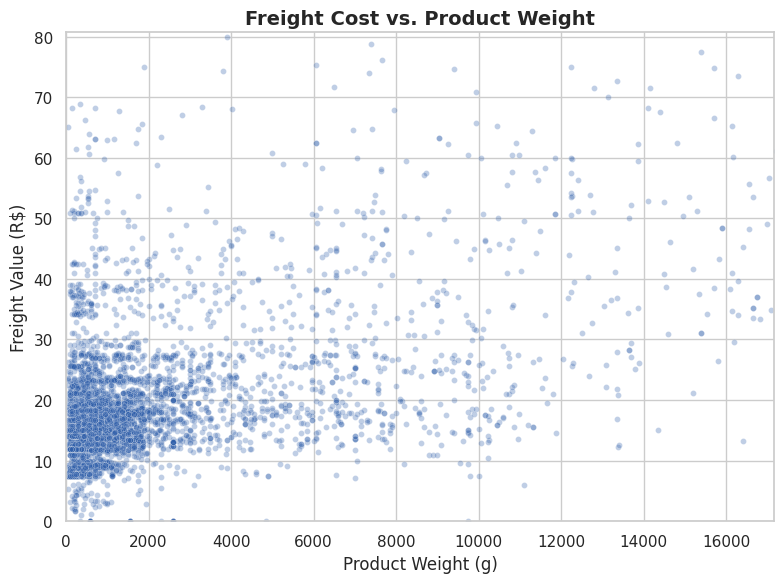

In [17]:
sample = df.sample(min(6000, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=sample, x='product_weight_g', y='freight_value', alpha=0.3, s=18, color=PALETTE, ax=ax)
ax.set_xlim(0, sample['product_weight_g'].quantile(0.99))
ax.set_ylim(0, sample['freight_value'].quantile(0.99))
ax.set_title('Freight Cost vs. Product Weight', fontsize=14, weight='bold')
ax.set_xlabel('Product Weight (g)')
ax.set_ylabel('Freight Value (R$)')
plt.tight_layout()
plt.show()


**Insight:** Freight rises with weight but with wide dispersion at every level — weight alone doesn't fully determine cost; carrier zone and dimensional weight likely play a role too.

### 3.6 Correlation Heatmap

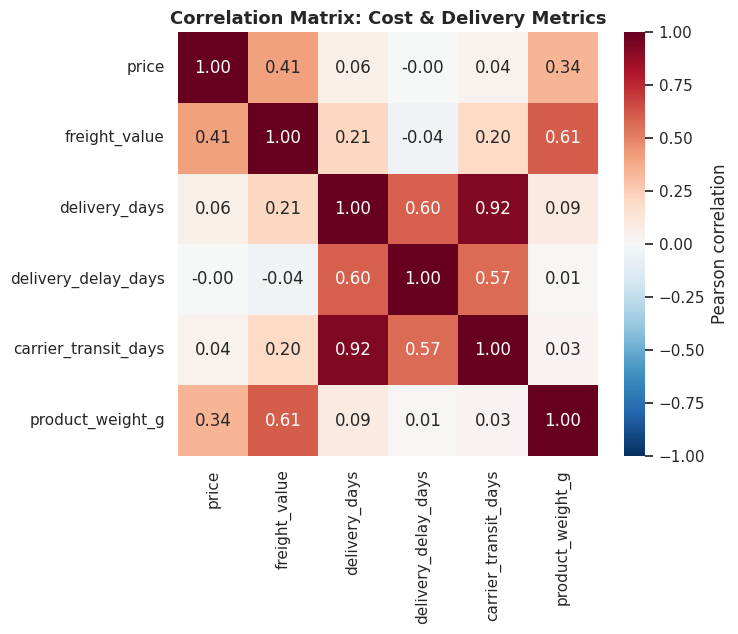

In [18]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={'label': 'Pearson correlation'})
ax.set_title('Correlation Matrix: Cost & Delivery Metrics', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()


**Insight:** Carrier transit time (0.92) dwarfs price or weight as a driver of total delivery time — operational investment should target carrier/network performance.

### 3.7 Delivery Time Spread by Customer State

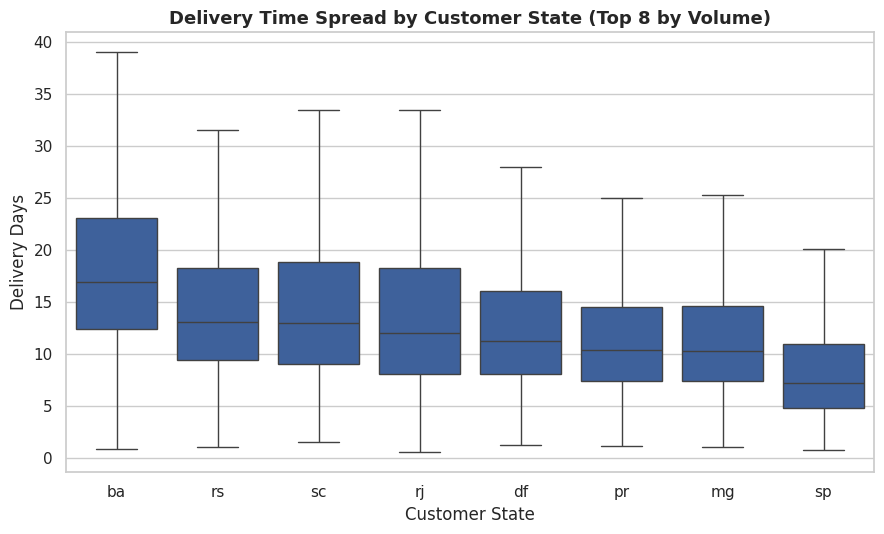

In [19]:
sub = delivered[delivered['customer_state'].isin(state_counts.index)]
order = sub.groupby('customer_state')['delivery_days'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=sub, x='customer_state', y='delivery_days', order=order, color=PALETTE, showfliers=False, ax=ax)
ax.set_title('Delivery Time Spread by Customer State (Top 8 by Volume)', fontsize=13, weight='bold')
ax.set_xlabel('Customer State')
ax.set_ylabel('Delivery Days')
plt.tight_layout()
plt.show()


**Insight:** States like Bahia (BA) and Espírito Santo (ES) show both higher median delivery time and wider spread than São Paulo (SP) — slower AND less predictable.

### 3.8 Late-Delivery Rate by Customer State

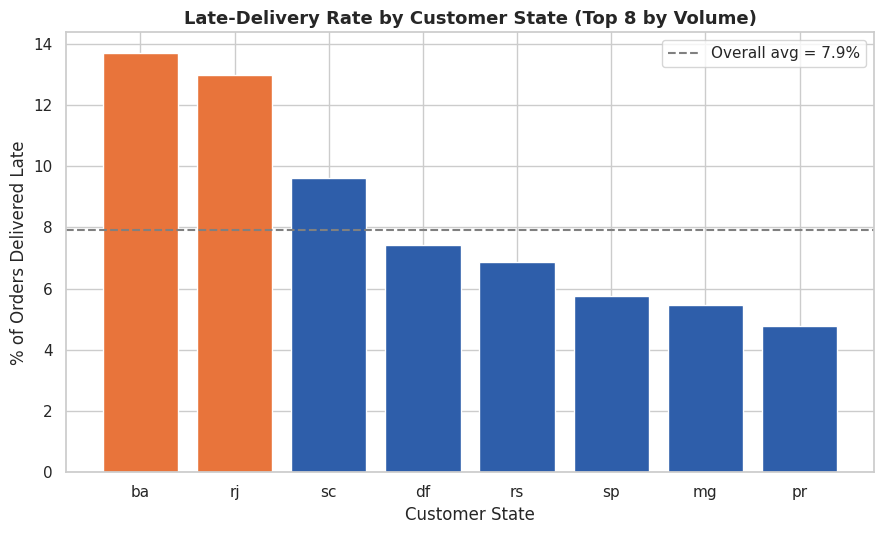

In [20]:
g3 = state_late_rate
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = [ACCENT if v > 10 else PALETTE for v in g3.values]
ax.bar(g3.index, g3.values, color=colors)
ax.axhline(delivered['is_late'].mean() * 100, color='gray', linestyle='--',
           label=f"Overall avg = {delivered['is_late'].mean()*100:.1f}%")
ax.set_title('Late-Delivery Rate by Customer State (Top 8 by Volume)', fontsize=13, weight='bold')
ax.set_xlabel('Customer State')
ax.set_ylabel('% of Orders Delivered Late')
ax.legend()
plt.tight_layout()
plt.show()


**Insight:** Bahia, Rio de Janeiro, and Espírito Santo run at roughly 1.5-1.7x the network late-delivery rate — strong candidates for regional carrier renegotiation.

### 3.9 Same-State vs. Cross-State Shipments

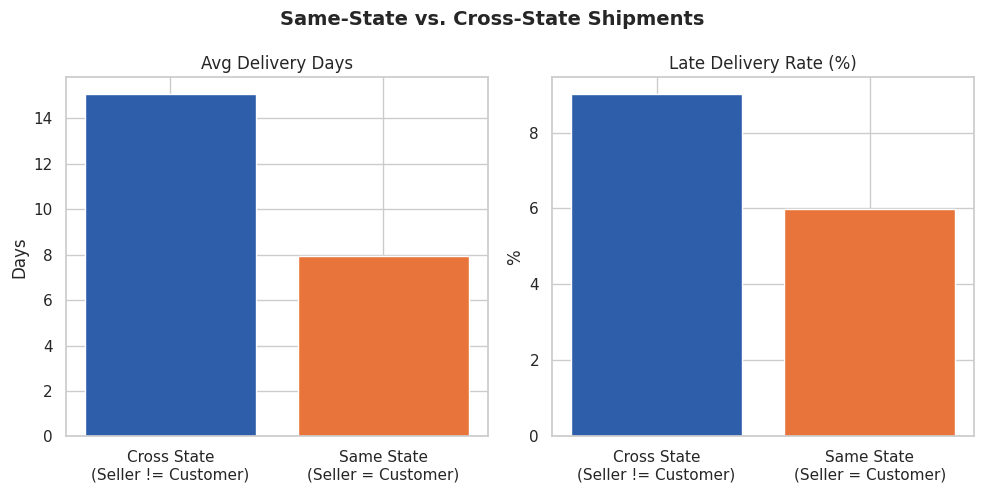

In [21]:
comp = delivered.groupby('same_state').agg(
    avg_delivery=('delivery_days', 'mean'),
    late_rate=('is_late', lambda x: x.mean() * 100)
).rename(index={True: 'Same State\n(Seller = Customer)', False: 'Cross State\n(Seller != Customer)'})

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].bar(comp.index, comp['avg_delivery'], color=[PALETTE, ACCENT])
axes[0].set_title('Avg Delivery Days')
axes[0].set_ylabel('Days')
axes[1].bar(comp.index, comp['late_rate'], color=[PALETTE, ACCENT])
axes[1].set_title('Late Delivery Rate (%)')
axes[1].set_ylabel('%')
fig.suptitle('Same-State vs. Cross-State Shipments', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


**Insight:** Cross-state shipments take almost 2x as long (15.0 vs 7.9 days) and are 50% more likely to be late — shipment distance is the single largest bottleneck identified in this dataset.

### 3.10 Order Price vs. Freight Value

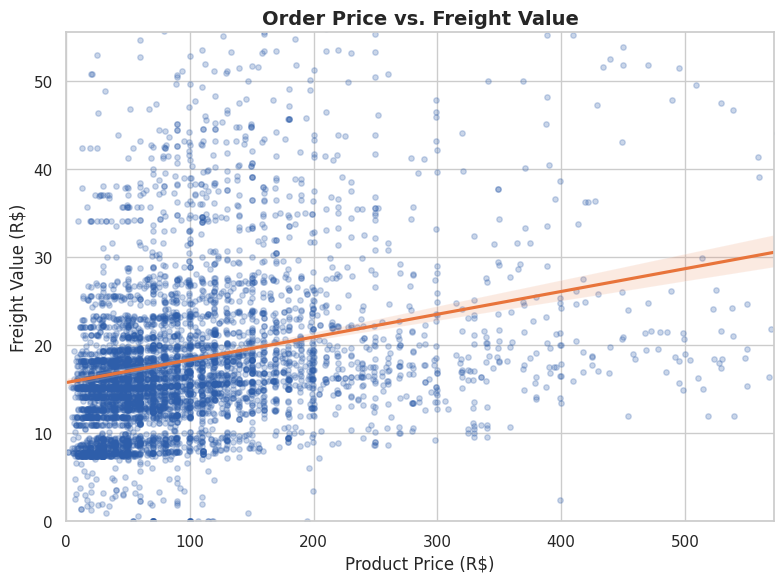

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
sample2 = df[df['freight_outlier'] == False].sample(min(6000, len(df)), random_state=1)
sns.regplot(data=sample2, x='price', y='freight_value',
            scatter_kws={'alpha': 0.25, 's': 15, 'color': PALETTE},
            line_kws={'color': ACCENT}, ax=ax)
ax.set_xlim(0, sample2['price'].quantile(0.98))
ax.set_ylim(0, sample2['freight_value'].quantile(0.98))
ax.set_title('Order Price vs. Freight Value', fontsize=14, weight='bold')
ax.set_xlabel('Product Price (R$)')
ax.set_ylabel('Freight Value (R$)')
plt.tight_layout()
plt.show()


**Insight:** Freight rises gently with price but the relationship is noisy — freight pricing is driven more by physical shipping characteristics than by declared value.

## 4. Summary of Key Findings

- **Median delivery time:** 10.2 days (mean 12.5); only **7.9%** of orders arrive later than the estimated date.
- **Carrier transit time is the dominant driver** of total delivery time (r = 0.92), far more than price or weight.
- **Same-state shipments deliver in 7.9 days** on average vs. **15.0 days for cross-state** shipments, with a lower late rate (6.0% vs 9.0%).
- **Bahia, Espírito Santo, and Goiás** are consistently the slowest and least reliable states; **São Paulo** is fastest and most reliable.
- **Freight cost scales with weight** (r = 0.61) more than with price (r = 0.41), consistent with weight-based carrier pricing.
- **Office furniture** and other bulky categories take structurally longer to deliver.

### Recommendations
1. Prioritize regional fulfillment/micro-warehousing near underperforming states (BA, ES, GO).
2. Renegotiate carrier contracts for slow lanes, since transit time — not internal processing — drives delay.
3. Build seasonal capacity buffers ahead of known demand peaks (e.g., November).
4. Review packaging/dimensional-weight practices for bulky categories to reduce freight cost.
5. Consider tightening estimated-delivery-date promises given consistent early delivery.
